**Introduction to Python Imaging Library(PIL)**

Exercise- 1:
1. Read and display the image.
• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image.

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

# Open the image
img = Image.open("/content/drive/MyDrive/AI_SEM5/Doreman.png")

# Display image
img.show()

print("Image opened and displayed successfully using Pillow.")

Image opened and displayed successfully using Pillow.


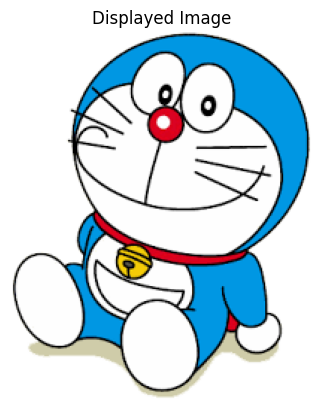

Image displayed using Matplotlib.


In [21]:

# Display image using matplotlib
plt.imshow(img)
plt.axis("off")   # hides axis
plt.title("Displayed Image")
plt.show()

print("Image displayed using Matplotlib.")

**2. Display only the top left corner of 100x100 pixels.**
• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.

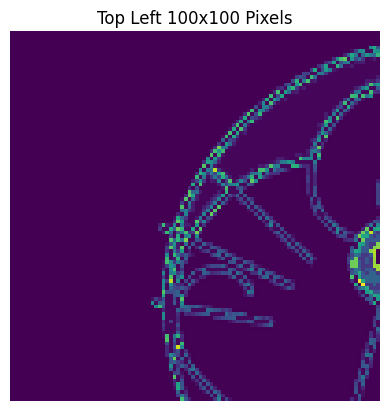

Top-left corner displayed


In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy array
img_array = np.array(img)

# Extract top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

# Display
plt.imshow(top_left)
plt.axis("off")
plt.title("Top Left 100x100 Pixels")
plt.show()

print("Top-left corner displayed")

**3. Show the three color channels (R, G, B).**
• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

Image shape: (248, 203)
The image is grayscale, so the same values are used for R, G, and B.


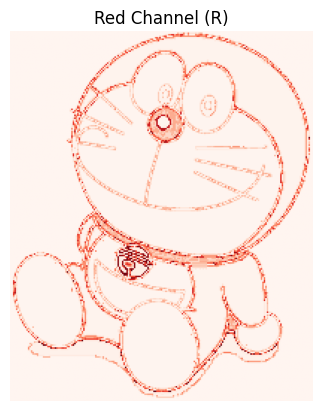

In [14]:
# Print the shape of the image array
print("Image shape:", img_array.shape)

# Check whether the image is grayscale or RGB
if len(img_array.shape) == 2:
    # If the image is grayscale, it has only one channel
    # So we use the same channel for Red, Green, and Blue
    R = img_array
    G = img_array
    B = img_array

    print("The image is grayscale, so the same values are used for R, G, and B.")

elif len(img_array.shape) == 3 and img_array.shape[2] == 3:
    # If the image is a color image, separate the channels
    R = img_array[:, :, 0]   # Red channel
    G = img_array[:, :, 1]   # Green channel
    B = img_array[:, :, 2]   # Blue channel

else:
    # If the image format is unexpected
    raise ValueError("Unsupported image format")

# Display Red channel
plt.imshow(R, cmap="Reds")
plt.title("Red Channel (R)")
plt.axis("off")
plt.show()

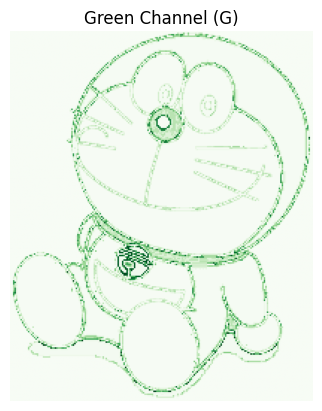

In [15]:
# Display Green channel
plt.imshow(G, cmap="Greens")
plt.title("Green Channel (G)")
plt.axis("off")
plt.show()

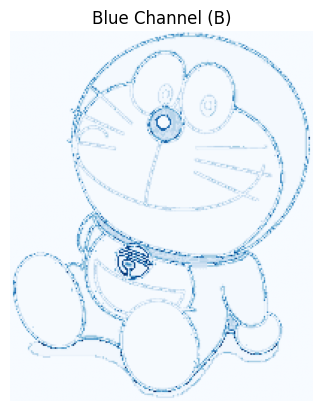

In [16]:
# Display Blue channel
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel (B)")
plt.axis("off")
plt.show()

**4. Modify the top 100 ×100 pixels to a value of 210 and display the resulting image:**
• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

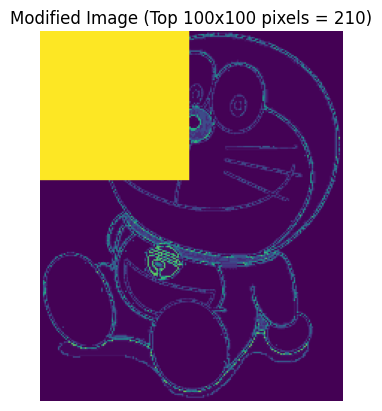

Top-left pixels modified to 210


In [17]:

# Modify top-left region
img_array[0:100, 0:100] = 210

# Display modified image
plt.imshow(img_array)
plt.axis("off")
plt.title("Modified Image (Top 100x100 pixels = 210)")
plt.show()

print("Top-left pixels modified to 210")

**2.2 Exercise- 2:**

1. Load and display a grayscale image.

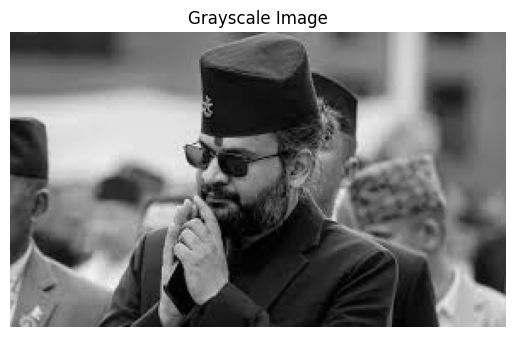

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

# Load image and convert to grayscale
img = Image.open("/content/drive/MyDrive/AI_SEM5/balen.jpg").convert("L")

# Display the grayscale image
plt.imshow(img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Extract and display the middle section of the image (150 pixels).

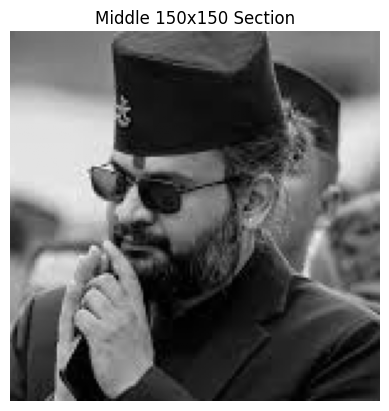

In [24]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy array
img_array = np.array(img)

# Get image dimensions
h, w = img_array.shape

# Extract 150x150 section from center
center = img_array[h//2-75:h//2+75, w//2-75:w//2+75]

# Display cropped image
plt.imshow(center, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

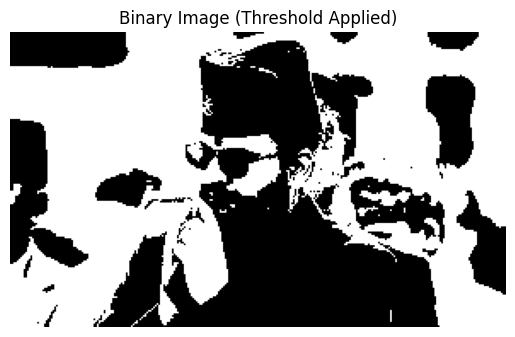

In [25]:

# Apply threshold
binary = np.where(img_array < 100, 0, 255)

# Display binary image
plt.imshow(binary, cmap="gray")
plt.title("Binary Image (Threshold Applied)")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.


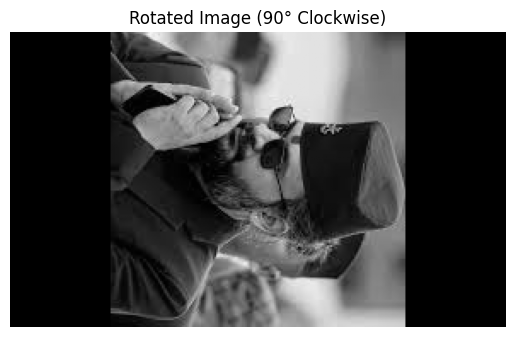

In [26]:

# Rotate 90 degrees clockwise
rotated = img.rotate(-90)

# Display rotated image
plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

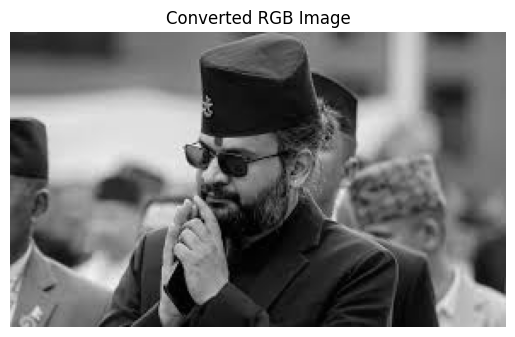

In [27]:

# Convert to numpy array
img_array = np.array(img)

# Convert grayscale to RGB by stacking channels
rgb_img = np.stack((img_array, img_array, img_array), axis=-1)

# Display RGB image
plt.imshow(rgb_img)
plt.title("Converted RGB Image")
plt.axis("off")
plt.show()

**3 Image Compression and Decompression using PCA.**

1. Load and Prepare Data:


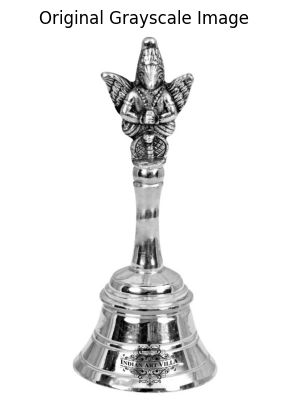

Covariance matrix shape: (1520, 1520)


In [28]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image and convert to grayscale
img = Image.open("/content/drive/MyDrive/AI_SEM5/bell.webp").convert("L")
img_array = np.array(img, dtype=float)

# Display original grayscale image
plt.imshow(img_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

# Center the dataset (subtract mean of each column)
mean_img = np.mean(img_array, axis=0)
centered_data = img_array - mean_img

# Compute the covariance matrix
cov_matrix = np.cov(centered_data.T)
print("Covariance matrix shape:", cov_matrix.shape)

2. Eigen Decomposition and Identifying Principal Components:

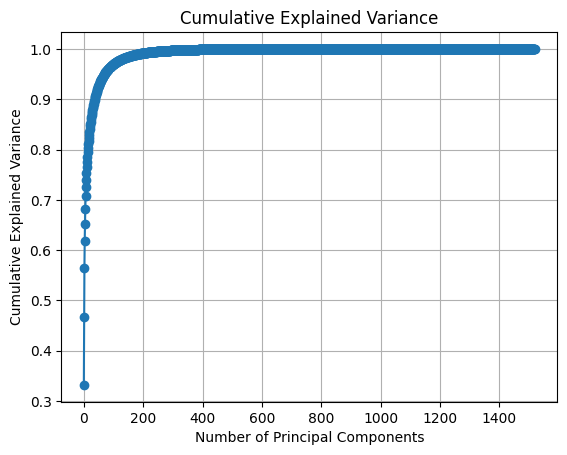

In [29]:
# Compute eigenvalues and eigenvectors
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_idx]
eig_vecs = eig_vecs[:, sorted_idx]

# Compute explained variance
explained_variance = eig_vals / np.sum(eig_vals)
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative explained variance to choose top k PCs
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid()
plt.show()

3. Reconstruction and Experiment:
.

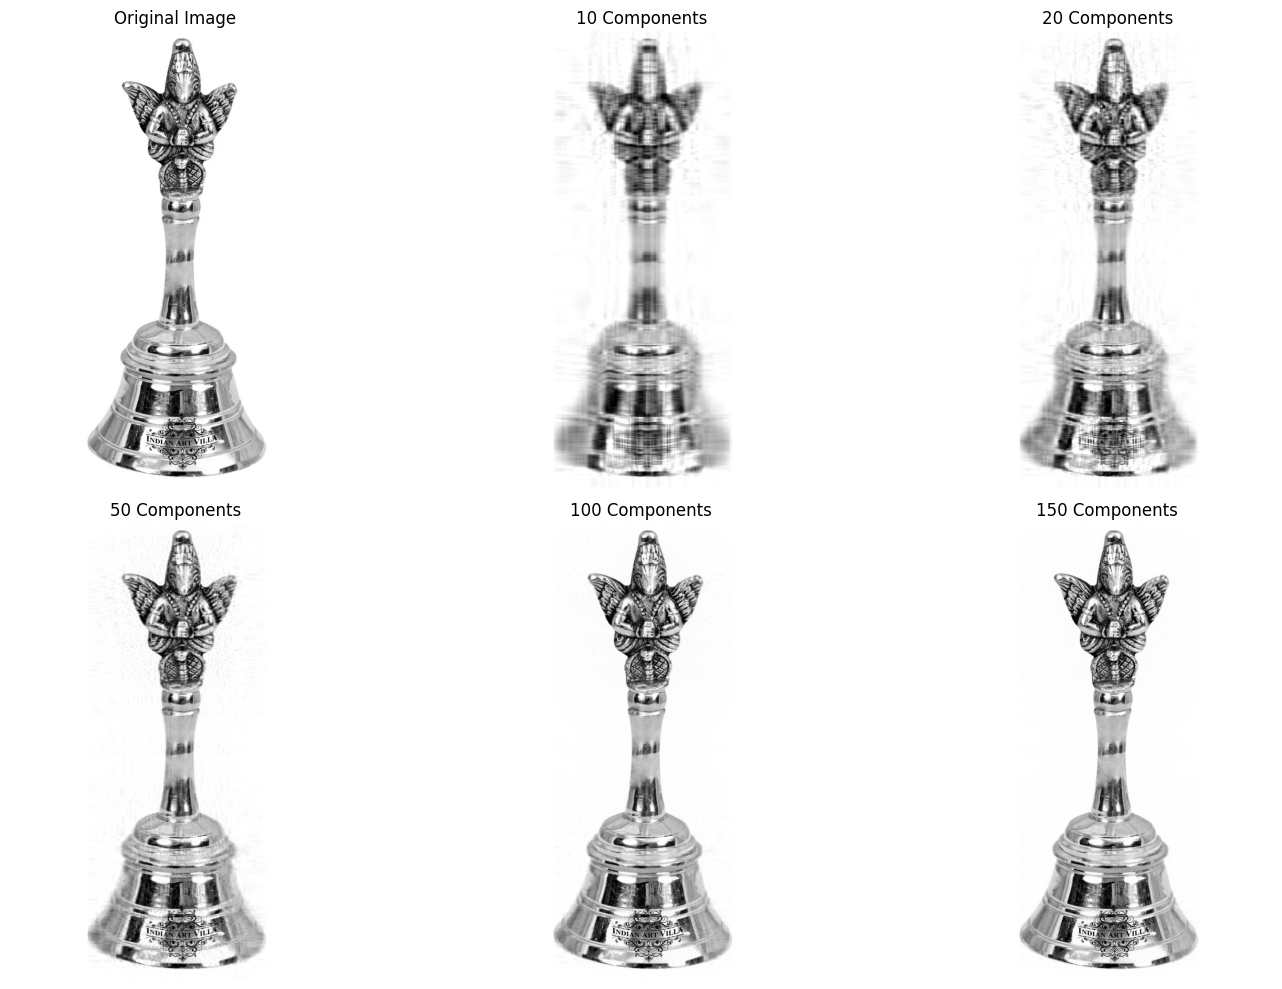

In [32]:


# Covariance matrix
cov_matrix = np.cov(centered_data.T)

# Eigen decomposition
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_idx]
eig_vecs = eig_vecs[:, sorted_idx]

# Function to reconstruct image with k principal components
def reconstruct_image(data, mean, eigvecs, k):
    top_eigvecs = eigvecs[:, :k]
    projected = np.dot(data, top_eigvecs)
    reconstructed = np.dot(projected, top_eigvecs.T) + mean
    return np.clip(reconstructed, 0, 255)

# Choose number of components to experiment with
components_list = [10, 20, 50, 100, 150]

# Plot original and reconstructed images
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()

# Original image
axs[0].imshow(img_array, cmap="gray")
axs[0].set_title("Original Image")
axs[0].axis("off")

# Reconstructed images with different PCs
for i, k in enumerate(components_list):
    recon = reconstruct_image(centered_data, mean_img, eig_vecs, k)
    axs[i+1].imshow(recon, cmap="gray")
    axs[i+1].set_title(f"{k} Components")
    axs[i+1].axis("off")

plt.tight_layout()
plt.show()